# Task 5: Per-Tensor and Per-Channel Quantization

## Objective

Compare **per-tensor** and **per-output-channel symmetric quantization** for convolution weights. Understand why **per-channel quantization** preserves accuracy better when channels have different value ranges.

---

## Input

Generate a 4D convolution weight tensor with deliberately imbalanced channel ranges.

```python
np.random.seed(42)

conv_weights = np.random.randn(8, 3, 3, 3).astype(np.float32)

# Create range imbalance across output channels
conv_weights[0] *= 0.1    # very small range
conv_weights[1] *= 0.5    # small range
conv_weights[6] *= 5.0    # large range
conv_weights[7] *= 10.0   # very large range
```

### Tensor Shape

```text
[out_channels=8, in_channels=3, kernel_height=3, kernel_width=3]
```

---

# Part A: Per-Tensor Symmetric Quantization

Use a **single scale** for the entire weight tensor.

### Scale

```text
scale = max(|weight_tensor|) / 127
```

### Implementation

```python
def per_tensor_quantize(tensor):
    """
    Perform per-tensor symmetric quantization.

    Returns:
        quantized_tensor
        dequantized_tensor
        scale
    """
    pass
```

---

# Part B: Per-Output-Channel Symmetric Quantization

Use **one scale for each output channel** (axis 0).

### Scale

```text
scale[c] = max(|weight_tensor[c]|) / 127
```

### Implementation

```python
def per_channel_quantize(tensor):
    """
    Perform per-output-channel symmetric quantization.

    Returns:
        quantized_tensor
        dequantized_tensor
        scales_array
    """
    pass
```

---

# Expected Output

Compute the quantization statistics for every output channel.

| Channel | Range (min, max) | Per-Tensor Scale | Per-Tensor MAE | Per-Channel Scale | Per-Channel MAE | Better |
|--------:|------------------|-----------------:|---------------:|------------------:|----------------:|:-------|
| 0 | | | | | | |
| 1 | | | | | | |
| 2 | | | | | | |
| 3 | | | | | | |
| 4 | | | | | | |
| 5 | | | | | | |
| 6 | | | | | | |
| 7 | | | | | | |
| **Average** | | | | | | |

---

# Deliverable

Your notebook should include:

- ✅ Implementation of per-tensor symmetric quantization
- ✅ Implementation of per-output-channel symmetric quantization
- ✅ Completed comparison table for all output channels
- ✅ Error metrics (MAE) for every channel
- ✅ Written answers to the analysis questions, discussing:
  - Why per-channel quantization performs better for channels with different value ranges
  - How a single global scale affects channels with very small values
  - The impact of range imbalance on quantization error
  - Why modern deep learning frameworks commonly use per-channel quantization 

In [1]:
import torch
import numpy as np
import pandas as pd

In [2]:
np.random.seed(42)

conv_weights = np.random.randn(8, 3, 3, 3).astype(np.float32)

# Create different dynamic ranges
conv_weights[0] *= 0.1
conv_weights[1] *= 0.5
conv_weights[6] *= 5.0
conv_weights[7] *= 10.0

conv_weights = torch.tensor(conv_weights)

In [3]:
def per_tensor_quantize(tensor):

    qmin = -127
    qmax = 127

    scale = torch.max(torch.abs(tensor)).item() / qmax

    if scale == 0:
        scale = 1.0

    quantized = torch.round(tensor / scale)
    quantized = torch.clamp(quantized, qmin, qmax).to(torch.int8)

    dequantized = quantized.float() * scale

    return quantized, dequantized, scale

In [4]:
def per_channel_quantize(tensor):

    qmin = -127
    qmax = 127

    quantized = torch.zeros_like(tensor, dtype=torch.int8)
    dequantized = torch.zeros_like(tensor)

    scales = []

    for c in range(tensor.shape[0]):

        channel = tensor[c]

        scale = torch.max(torch.abs(channel)).item() / qmax

        if scale == 0:
            scale = 1.0

        q = torch.round(channel / scale)
        q = torch.clamp(q, qmin, qmax).to(torch.int8)

        dq = q.float() * scale

        quantized[c] = q
        dequantized[c] = dq

        scales.append(scale)

    return quantized, dequantized, np.array(scales)

In [5]:
q_tensor, dq_tensor, tensor_scale = per_tensor_quantize(conv_weights)

q_channel, dq_channel, channel_scales = per_channel_quantize(conv_weights)

In [6]:
results = []

for c in range(conv_weights.shape[0]):

    original = conv_weights[c]

    mae_tensor = torch.mean(
        torch.abs(original - dq_tensor[c])
    ).item()

    mae_channel = torch.mean(
        torch.abs(original - dq_channel[c])
    ).item()

    better = (
        "Per-Channel"
        if mae_channel < mae_tensor
        else "Per-Tensor"
    )

    results.append({

        "Channel": c,

        "Range (min,max)":
        f"({original.min().item():.3f}, {original.max().item():.3f})",

        "Per-Tensor Scale":
        tensor_scale,

        "Per-Tensor MAE":
        mae_tensor,

        "Per-Ch Scale":
        channel_scales[c],

        "Per-Ch MAE":
        mae_channel,

        "Better":
        better
    })

df = pd.DataFrame(results)
df

,Channel,"Range (min,max)",Per-Tensor Scale,Per-Tensor MAE,Per-Ch Scale,Per-Ch MAE,Better
0,0,"(-0.191, 0.158)",0.303365,0.071464,0.001507,0.000326,Per-Channel
1,1,"(-0.980, 0.926)",0.303365,0.072564,0.007715,0.001661,Per-Channel
2,2,"(-2.620, 1.565)",0.303365,0.072175,0.020628,0.005373,Per-Channel
3,3,"(-1.464, 1.886)",0.303365,0.071594,0.014852,0.003731,Per-Channel
4,4,"(-1.919, 2.463)",0.303365,0.070571,0.019396,0.003995,Per-Channel
5,5,"(-1.607, 1.866)",0.303365,0.068939,0.014691,0.003901,Per-Channel
6,6,"(-5.354, 13.601)",0.303365,0.077800,0.107093,0.027714,Per-Channel
7,7,"(-15.148, 38.527)",0.303365,0.064038,0.303365,0.064038,Per-Tensor


In [7]:
average = {

    "Channel": "Average",

    "Range (min,max)": "-",

    "Per-Tensor Scale":
    df["Per-Tensor Scale"].mean(),

    "Per-Tensor MAE":
    df["Per-Tensor MAE"].mean(),

    "Per-Ch Scale":
    df["Per-Ch Scale"].mean(),

    "Per-Ch MAE":
    df["Per-Ch MAE"].mean(),

    "Better": "-"
}

comparison = pd.concat(
    [df, pd.DataFrame([average])],
    ignore_index=True
)

comparison

,Channel,"Range (min,max)",Per-Tensor Scale,Per-Tensor MAE,Per-Ch Scale,Per-Ch MAE,Better
0,0,"(-0.191, 0.158)",0.303365,0.071464,0.001507,0.000326,Per-Channel
1,1,"(-0.980, 0.926)",0.303365,0.072564,0.007715,0.001661,Per-Channel
2,2,"(-2.620, 1.565)",0.303365,0.072175,0.020628,0.005373,Per-Channel
3,3,"(-1.464, 1.886)",0.303365,0.071594,0.014852,0.003731,Per-Channel
4,4,"(-1.919, 2.463)",0.303365,0.070571,0.019396,0.003995,Per-Channel
5,5,"(-1.607, 1.866)",0.303365,0.068939,0.014691,0.003901,Per-Channel
6,6,"(-5.354, 13.601)",0.303365,0.077800,0.107093,0.027714,Per-Channel
7,7,"(-15.148, 38.527)",0.303365,0.064038,0.303365,0.064038,Per-Tensor
8,Average,-,0.303365,0.071143,0.061156,0.013842,-


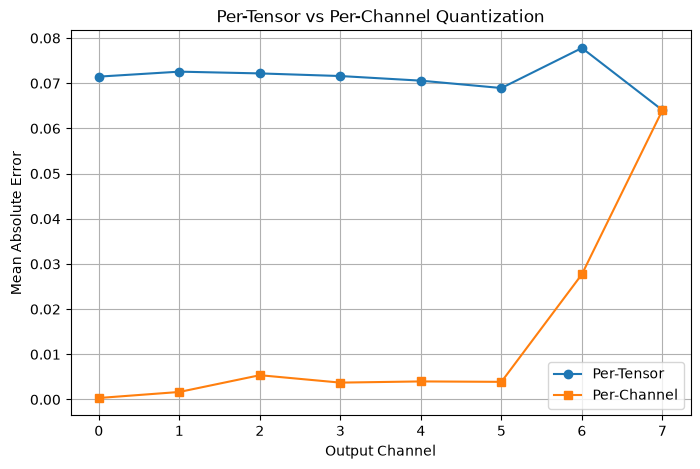

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    df["Channel"],
    df["Per-Tensor MAE"],
    marker="o",
    label="Per-Tensor"
)

plt.plot(
    df["Channel"],
    df["Per-Ch MAE"],
    marker="s",
    label="Per-Channel"
)

plt.xlabel("Output Channel")
plt.ylabel("Mean Absolute Error")
plt.title("Per-Tensor vs Per-Channel Quantization")
plt.grid(True)
plt.legend()

plt.show()